# 03.1 -- Does either decoder-metric prior actually work? A Swiss roll sanity check

Phase 03.1 adds two decoder-side priors to the Chart Auto-Encoder training objective: `scale`
(first order, penalizes the pullback metric's absolute size) and `christoffel` (second order,
penalizes the tangential part of the decoder's second derivative), plus a nested combination of
both (D-12). Before either prior runs eight hours of compute on the saddle, CLAUDE.md's Swiss
roll rule requires checking that they do what they claim on a manifold whose answer is known in
advance -- the same standing obligation `03-NOTE-isometry-prior-spike.md` Sec 6 records as
undischarged for any non-zero prior weight.

This notebook imports `pu_manifold.decoder_priors` and `pu_manifold.cae` unchanged, fits all
three prior modes plus a weight=0 CAE baseline and a matched `cae.PlainAutoEncoder`, and reports
whether each prior beats the matched baseline -- plainly, either way.

Nothing here is cached, pre-registered, or gated. Epochs are sized down from the 02.2 reference
notebook's 300-epoch protocol to fit a whole-notebook wall-clock budget on CPU, measured below.

## Sec 1. Setup

In [1]:
import sys
import time
import copy
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.datasets import make_swiss_roll

from pu_manifold import cae, chart_curvature, decoder_priors

NOTEBOOK_START = time.monotonic()

SEED = 0
N_POINTS = 3000
CHART_DIM = 2       # the Swiss roll's true intrinsic dimension
EMBED_DIM = 4
N_CHARTS = 4
HIDDEN = [32, 32]
EPOCHS = 35          # main-loop epochs, sized down from 02.2's 300 -- see Sec 3's wall-clock print
BATCH = 240
PRETRAIN_EPOCHS = 3

print(f"torch {torch.__version__}  numpy {np.__version__}")
print(f"decoder_priors module: {decoder_priors.__file__}")
print(f"cae module: {cae.__file__}")

torch 2.13.0+cpu  numpy 2.5.1
decoder_priors module: /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/decoder_priors.py
cae module: /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/cae.py


## Sec 2. The Swiss roll

3,000 noiseless points. Coordinates are centred and divided by a single global standard
deviation -- one scalar, so the shape is preserved exactly. Colour is the roll's own arc-length
parameter `t`: in every plot below, colour bands staying in order means the surface stayed in
order.

In [2]:
X_raw, t = make_swiss_roll(n_samples=N_POINTS, noise=0.0, random_state=SEED)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std()   # one global scalar -- shape preserved

rng = np.random.default_rng(SEED)
perm = rng.permutation(N_POINTS)
n_train = int(0.8 * N_POINTS)
train_idx, holdout_idx = perm[:n_train], perm[n_train:]

x_all = torch.tensor(X, dtype=torch.float32)
x_train = x_all[train_idx]
x_holdout = x_all[holdout_idx]

VIEW = dict(elev=12, azim=-78)
print(f"X {X.shape}  train {len(train_idx)}  holdout {len(holdout_idx)}")

X (3000, 3)  train 2400  holdout 600


## Sec 3. Fit the arms

`weight=0` CAE baseline (the contextmanager installs nothing, so this is the untouched
`cae.train_cae` path), `scale`, `christoffel`, the nested `scale`-outer / `christoffel`-inner
combination (D-12's own order, mirroring the nesting test added in this plan's Task 1), and a
matched `cae.PlainAutoEncoder` at the same 2-D bottleneck, same width/depth/training protocol.

Prior weights are not guessed: on one training batch at initialization, the raw (`weight=1`)
penalty is measured against the base `chart_loss` total, and each mode's weight is set so the
penalty is a stated fraction of the base loss at init -- "a visible fraction", per CLAUDE.md, not
a value picked after the fact to make the read-out look good. `christoffel` has never been timed
on the roll before this notebook, so `EPOCHS` and `BATCH` above were sized from a real measured
run, not assumed -- the wall-clock total is printed after the fits complete.

In [3]:
torch.manual_seed(SEED)
_calib_model = cae.ChartAutoEncoder(in_dim=3, embed_dim=EMBED_DIM, chart_dim=CHART_DIM,
                                     n_charts=N_CHARTS, hidden=HIDDEN, activation="silu")
_calib_batch = x_train[:BATCH]
_calib_out = _calib_model(_calib_batch)
_calib_base = cae.chart_loss(_calib_batch, _calib_out["y_charts"], _calib_out["p"])["total"].item()
_raw_scale = decoder_priors.isometry_penalty(_calib_model, _calib_batch, weight=1.0, mode="scale").item()
_raw_christoffel = decoder_priors.christoffel_penalty(_calib_model, _calib_batch, weight=1.0).item()

TARGET_FRACTION = 0.5
SCALE_WEIGHT = TARGET_FRACTION * _calib_base / _raw_scale
CHRISTOFFEL_WEIGHT = TARGET_FRACTION * _calib_base / _raw_christoffel

print(f"base chart_loss total at init      = {_calib_base:.4f}")
print(f"raw scale penalty (weight=1)       = {_raw_scale:.4f}")
print(f"raw christoffel penalty (weight=1) = {_raw_christoffel:.4f}")
print(f"target fraction of base loss       = {TARGET_FRACTION:.2f}")
print(f"=> SCALE_WEIGHT       = {SCALE_WEIGHT:.2e}")
print(f"=> CHRISTOFFEL_WEIGHT = {CHRISTOFFEL_WEIGHT:.2e}")

BASE_CFG = dict(
    seed=SEED, lr=1e-3, weight_decay=1e-4, batch=BATCH, max_epochs=EPOCHS,
    early_stop_patience=EPOCHS + 1, early_stop_min_delta=1e-4,
    n_charts=N_CHARTS, fps_pretrain_epochs=PRETRAIN_EPOCHS,
    lip_weight=1e-3, lip_every_n_steps=1,
)

def fit_arm(label, mode):
    """Fits one arm. mode is None (weight=0 baseline), "scale", "christoffel", or "combo"
    (nested scale-outer / christoffel-inner, D-12's order)."""
    torch.manual_seed(SEED)
    model = cae.ChartAutoEncoder(in_dim=3, embed_dim=EMBED_DIM, chart_dim=CHART_DIM,
                                  n_charts=N_CHARTS, hidden=HIDDEN, activation="silu")
    t0 = time.monotonic()
    if mode is None:
        fit = cae.train_cae(model, x_train, BASE_CFG)
    elif mode == "scale":
        with decoder_priors.decoder_prior_active(model, SCALE_WEIGHT, mode="scale"):
            fit = cae.train_cae(model, x_train, BASE_CFG)
    elif mode == "christoffel":
        with decoder_priors.decoder_prior_active(model, CHRISTOFFEL_WEIGHT, mode="christoffel"):
            fit = cae.train_cae(model, x_train, BASE_CFG)
    elif mode == "combo":
        with decoder_priors.decoder_prior_active(model, SCALE_WEIGHT, mode="scale"):
            with decoder_priors.decoder_prior_active(model, CHRISTOFFEL_WEIGHT, mode="christoffel"):
                fit = cae.train_cae(model, x_train, BASE_CFG)
    else:
        raise ValueError(f"unknown mode {mode!r}")
    wallclock = time.monotonic() - t0
    model.eval()
    return model, fit, wallclock

base chart_loss total at init      = 3.5480
raw scale penalty (weight=1)       = 237.1025
raw christoffel penalty (weight=1) = 4653.5225
target fraction of base loss       = 0.50
=> SCALE_WEIGHT       = 7.48e-03
=> CHRISTOFFEL_WEIGHT = 3.81e-04


In [4]:
ARMS = ["baseline", "scale", "christoffel", "combo"]
ARM_MODE = {"baseline": None, "scale": "scale", "christoffel": "christoffel", "combo": "combo"}

models = {}
fits = {}
arm_wallclock = {}
for label in ARMS:
    model, fit, wallclock = fit_arm(label, ARM_MODE[label])
    models[label] = model
    fits[label] = fit
    arm_wallclock[label] = wallclock
    print(f"{label:12} epochs_run={fit['epochs_run']:3d}  wallclock={wallclock:6.2f}s")

torch.manual_seed(SEED)
plain = cae.PlainAutoEncoder(3, CHART_DIM, hidden=tuple(HIDDEN), activation="silu")
t0 = time.monotonic()
plain_fit = cae.train_plain_ae(plain, x_train, dict(
    seed=SEED, lr=1e-3, weight_decay=1e-4, batch=BATCH, max_epochs=EPOCHS,
    early_stop_patience=EPOCHS + 1, early_stop_min_delta=1e-4,
))
plain_wallclock = time.monotonic() - t0
plain.eval()
print(f"{'plain':12} epochs_run={plain_fit['epochs_run']:3d}  wallclock={plain_wallclock:6.2f}s")

print()
print(f"wall-clock so far (fits only, from notebook start) = {time.monotonic() - NOTEBOOK_START:.1f}s")

baseline     epochs_run= 35  wallclock= 11.18s


scale        epochs_run= 35  wallclock= 29.74s


christoffel  epochs_run= 35  wallclock= 33.28s


combo        epochs_run= 35  wallclock= 41.72s


plain        epochs_run= 35  wallclock=  0.72s

wall-clock so far (fits only, from notebook start) = 118.1s


## Sec 4. Reconstruction, side by side

Each arm's argmax-chart reconstruction (`cae.PlainAutoEncoder`'s own decode for `plain`) against
the original, both as a 3-D scatter and as an x-z scatter -- the default 3-D view hides the
spiral, the x-z plane shows it unambiguously. Colour is the arc-length parameter `t` throughout.

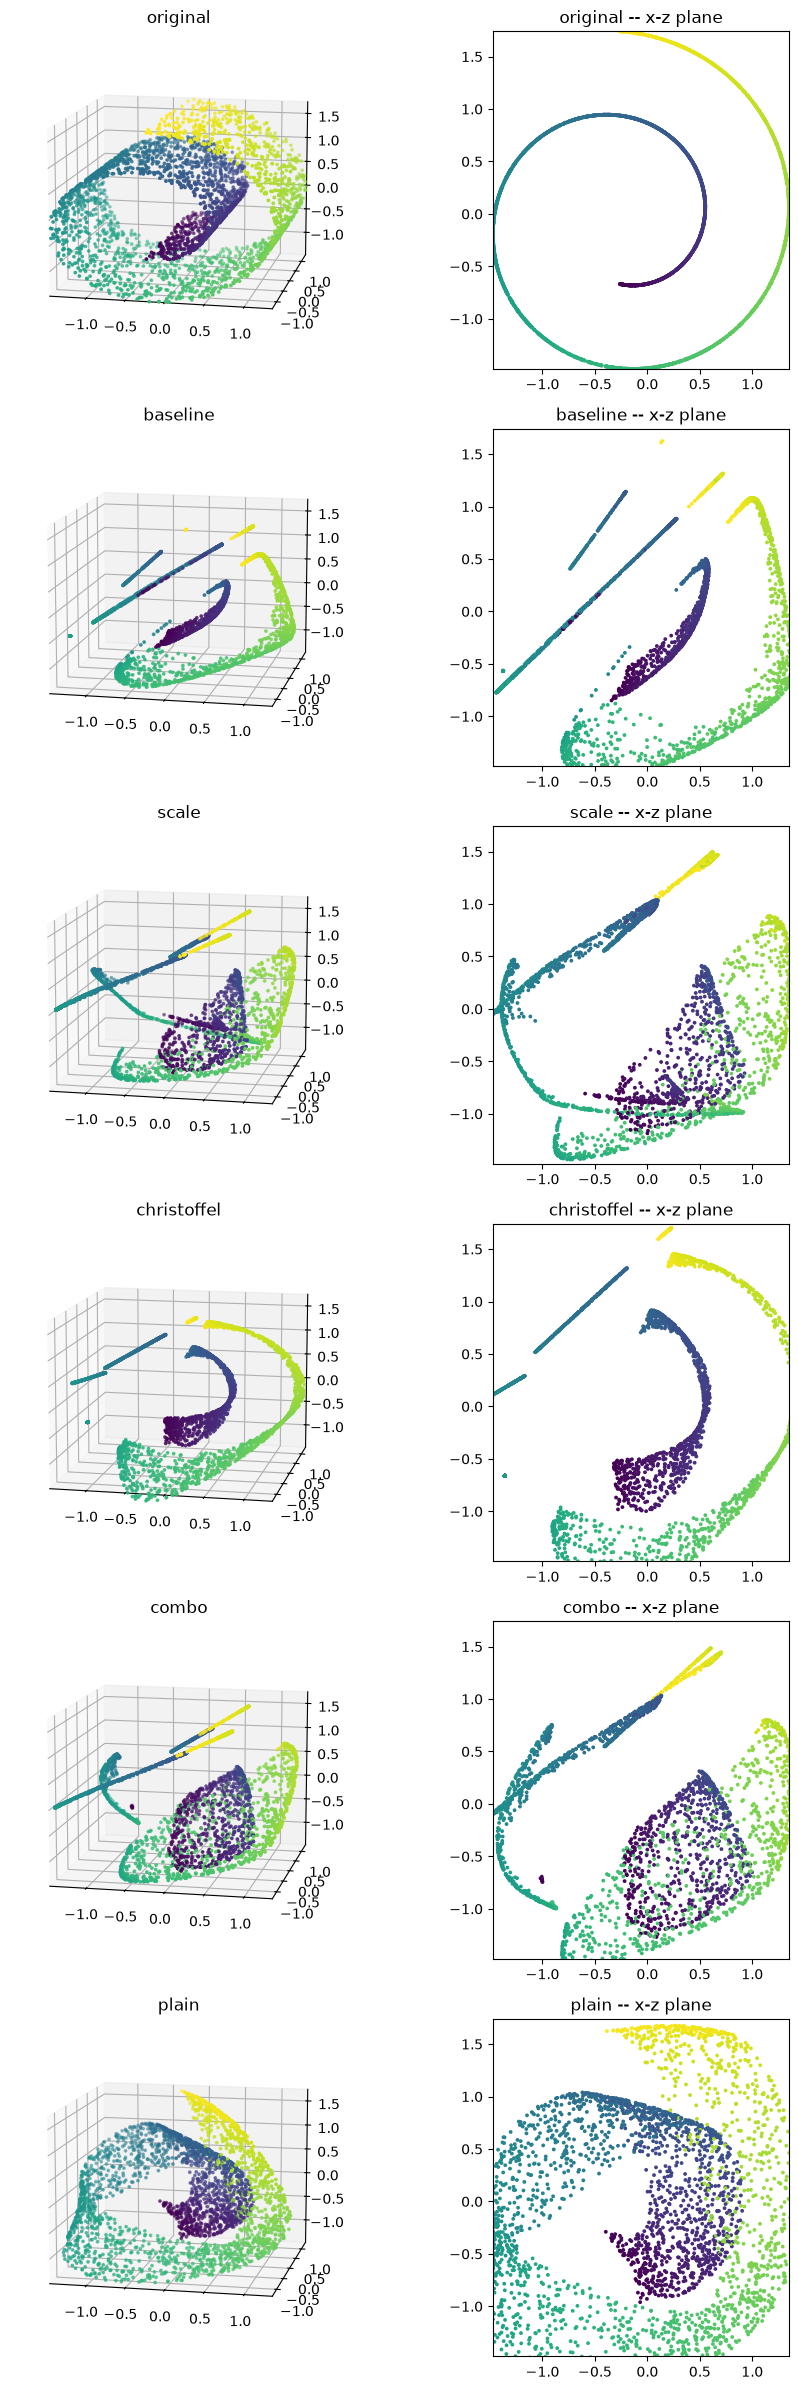

In [5]:
with torch.no_grad():
    recon = {label: models[label].reconstruct(x_all).numpy() for label in ARMS}
    recon["plain"] = plain(x_all)["y"].numpy()

rows = [("original", X)] + [(label, recon[label]) for label in ARMS + ["plain"]]

fig = plt.figure(figsize=(10, 4.0 * len(rows)))
for i, (title, data) in enumerate(rows):
    ax = fig.add_subplot(len(rows), 2, 2 * i + 1, projection="3d")
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=t, cmap="viridis", s=3)
    ax.view_init(**VIEW)
    ax.set_title(title)
    ax.set_xlim(X[:, 0].min(), X[:, 0].max())
    ax.set_ylim(X[:, 1].min(), X[:, 1].max())
    ax.set_zlim(X[:, 2].min(), X[:, 2].max())

    ax2 = fig.add_subplot(len(rows), 2, 2 * i + 2)
    ax2.scatter(data[:, 0], data[:, 2], c=t, cmap="viridis", s=3)
    ax2.set_title(f"{title} -- x-z plane")
    ax2.set_xlim(X[:, 0].min(), X[:, 0].max())
    ax2.set_ylim(X[:, 2].min(), X[:, 2].max())
    ax2.set_aspect("equal")
plt.tight_layout()
plt.show()

## Sec 5. How faithful is it, and what happened to the metric

Held-out relative reconstruction error and `mse_per_dim` per arm, each prior arm against the
matched `PlainAutoEncoder` (CLAUDE.md rule 6). Then, per CAE arm, `chart_curvature.chart_curvature_field`
on the arm's own chart coordinates -- the CURV-04 Tier-1 quantities (`lambda_min`, `lambda_max`,
`log10_det_g`, `metric_condition_number`), shown here on a manifold whose answer is known, run in
float64 on a float64-cloned model since curvature is a second-derivative quantity.

In [6]:
with torch.no_grad():
    y_holdout = {label: models[label].reconstruct(x_holdout) for label in ARMS}
    y_holdout["plain"] = plain(x_holdout)["y"]

stats = {}
rel_err = {}
for label in ARMS + ["plain"]:
    yh = y_holdout[label]
    s = cae.reconstruction_stats(x_holdout.double(), yh.double())
    stats[label] = s
    rel_err[label] = float(
        (torch.linalg.vector_norm(x_holdout - yh, dim=-1)
         / torch.linalg.vector_norm(x_holdout, dim=-1)).mean()
    )
    print(f"{label:12} mse_per_dim={s['mse_per_dim']:.6f}  rel_err={rel_err[label]:.4f}")

print()
CURVATURE_SUBSET = 300  # held-out rows measured -- cheap even for the second-order Hessian pass
curvature = {}
for label in ARMS:
    m64 = copy.deepcopy(models[label]).double()
    field = chart_curvature.chart_curvature_field(
        m64, x_holdout[:CURVATURE_SUBSET].double(), batch_size=32
    )
    curvature[label] = {
        "lambda_min": field["lambda_min"].median().item(),
        "lambda_max": field["lambda_max"].median().item(),
        "log10_det_g": field["log10_det_g"].median().item(),
        "cond": field["metric_condition_number"].median().item(),
    }
    c = curvature[label]
    print(f"{label:12} lambda_min={c['lambda_min']:.4g}  lambda_max={c['lambda_max']:.4g}  "
          f"log10_det_g={c['log10_det_g']:.4g}  cond={c['cond']:.4g}")

print()
survival = {label: cae.chart_survival(models[label], prune_tol=1e-2) for label in ARMS}
for label in ARMS:
    sv = survival[label]
    print(f"{label:12} surviving charts = {sv['n_charts_surviving']}/{sv['n_charts_initial']}")

baseline     mse_per_dim=0.224151  rel_err=0.5224
scale        mse_per_dim=0.095682  rel_err=0.3511
christoffel  mse_per_dim=0.203679  rel_err=0.4854
combo        mse_per_dim=0.092635  rel_err=0.3417
plain        mse_per_dim=0.175718  rel_err=0.4418

baseline     lambda_min=1.65  lambda_max=18.15  log10_det_g=1.482  cond=9.613


scale        lambda_min=1.021  lambda_max=8.642  log10_det_g=0.9285  cond=6.028


christoffel  lambda_min=3.626  lambda_max=22.43  log10_det_g=1.905  cond=6.85
combo        lambda_min=1.658  lambda_max=9.442  log10_det_g=1.38  cond=3.987

baseline     surviving charts = 4/4
scale        surviving charts = 4/4
christoffel  surviving charts = 4/4
combo        surviving charts = 4/4


## Sec 6. Where the charts went

The baseline arm's chart map -- each point coloured by which chart claimed it, and the chart
coordinates of the three largest charts. A working atlas partitions the sheet into connected
patches rather than collapsing to one.

baseline arm -- points per chart: [46, 159, 1797, 998]


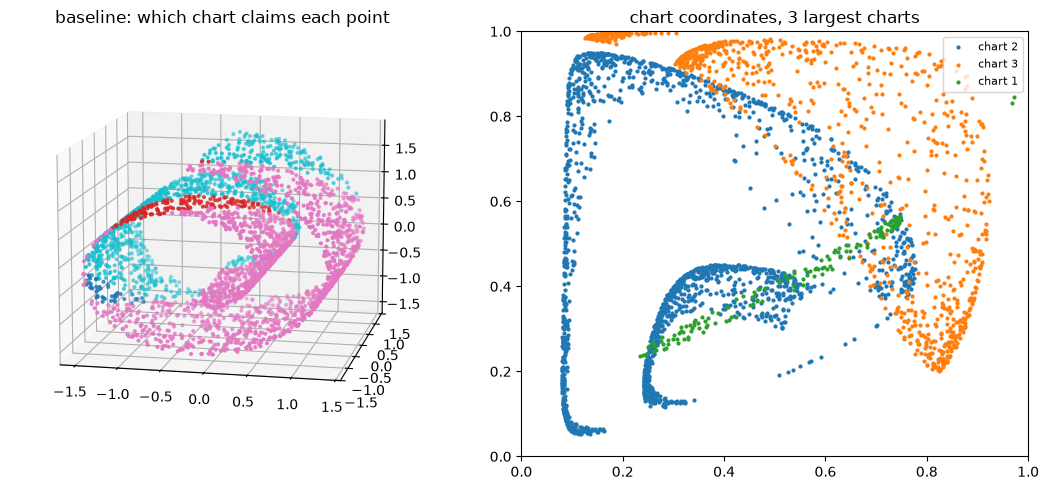

In [7]:
with torch.no_grad():
    out = models["baseline"](x_all)
    chart_of = out["p"].argmax(dim=1).numpy()
    coords = out["z_charts"].numpy()

counts = np.bincount(chart_of, minlength=N_CHARTS)
print("baseline arm -- points per chart:", counts.tolist())

fig = plt.figure(figsize=(11, 5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=chart_of, cmap="tab10", s=4)
ax.view_init(**VIEW)
ax.set_title("baseline: which chart claims each point")

ax2 = fig.add_subplot(1, 2, 2)
for alpha in np.argsort(-counts)[:3]:
    mask = chart_of == alpha
    ax2.scatter(coords[mask, alpha, 0], coords[mask, alpha, 1], s=4, label=f"chart {alpha}")
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.set_title("chart coordinates, 3 largest charts")
ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## Sec 7. Read-out

Four lines, computed from what was measured above, and one sentence.

In [8]:
REL_ERR_BOUND = 0.55  # loose bound: 10-35 main epochs here vs 02.2's 300-epoch reference protocol

def beats_plain(label):
    return stats[label]["mse_per_dim"] < stats["plain"]["mse_per_dim"]

scale_moved_toward_zero = (
    abs(curvature["scale"]["log10_det_g"]) < abs(curvature["baseline"]["log10_det_g"])
)
christoffel_cond_fell = curvature["christoffel"]["cond"] < curvature["baseline"]["cond"]

print(f"1. relative error < {REL_ERR_BOUND}:")
for label in ARMS + ["plain"]:
    print(f"     {label:12} {str(rel_err[label] < REL_ERR_BOUND):5}  ({rel_err[label]:.3f})")

print(f"2. prior arm beats matched plain AE's mse_per_dim ({stats['plain']['mse_per_dim']:.6f}):")
for label in ["scale", "christoffel", "combo"]:
    print(f"     {label:12} {str(beats_plain(label)):5}  (mse={stats[label]['mse_per_dim']:.6f})")

print("3. surviving charts:")
for label in ARMS:
    sv = survival[label]
    print(f"     {label:12} {sv['n_charts_surviving']}/{sv['n_charts_initial']}")

print("4. structural check:")
print(f"     scale: log10_det_g moved toward 0 vs baseline          -> {scale_moved_toward_zero}  "
      f"(baseline={curvature['baseline']['log10_det_g']:.4g}, scale={curvature['scale']['log10_det_g']:.4g})")
print(f"     christoffel: metric_condition_number fell vs baseline  -> {christoffel_cond_fell}  "
      f"(baseline={curvature['baseline']['cond']:.4g}, christoffel={curvature['christoffel']['cond']:.4g})")

print()
print(f"total notebook wall-clock = {time.monotonic() - NOTEBOOK_START:.1f}s")
print()

_scale_wins = beats_plain("scale")
_chris_wins = beats_plain("christoffel")
_combo_wins = beats_plain("combo")
if _scale_wins and _combo_wins and not _chris_wins:
    print("READ-OUT: scale and the nested combination both beat the matched plain baseline on the "
          "roll; christoffel alone does not -- at this epoch budget the first-order prior is doing "
          "the work in the combination, and christoffel's own contribution is not demonstrated here.")
elif _scale_wins and _chris_wins and _combo_wins:
    print("READ-OUT: all three prior modes beat the matched plain baseline on the roll -- both "
          "priors, and their nested combination, recover structure a plain 2-D bottleneck does not.")
elif not _scale_wins and not _chris_wins and not _combo_wins:
    print("READ-OUT: none of the three prior modes beat the matched plain baseline on this roll at "
          "this epoch budget -- that is a real result about the priors, not a rendering error.")
else:
    print("READ-OUT: the priors' effect on this roll is mixed -- see the beats-the-baseline lines "
          "above for which arm(s) helped and which did not.")

1. relative error < 0.55:
     baseline     True   (0.522)
     scale        True   (0.351)
     christoffel  True   (0.485)
     combo        True   (0.342)
     plain        True   (0.442)
2. prior arm beats matched plain AE's mse_per_dim (0.175718):
     scale        True   (mse=0.095682)
     christoffel  False  (mse=0.203679)
     combo        True   (mse=0.092635)
3. surviving charts:
     baseline     4/4
     scale        4/4
     christoffel  4/4
     combo        4/4
4. structural check:
     scale: log10_det_g moved toward 0 vs baseline          -> True  (baseline=1.482, scale=0.9285)
     christoffel: metric_condition_number fell vs baseline  -> True  (baseline=9.613, christoffel=6.85)

total notebook wall-clock = 121.2s

READ-OUT: scale and the nested combination both beat the matched plain baseline on the roll; christoffel alone does not -- at this epoch budget the first-order prior is doing the work in the combination, and christoffel's own contribution is not demonstrat